<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [6]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предложения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [7]:
sent_tokenize(dataset['train']['text'][3])

["This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo.",
 'Apart from that, what strikes me most is the endless stream of silliness.',
 'Lena Nyman has to be most annoying actress in the world.',
 "She acts so stupid and with all the nudity in this film,...it's unattractive.",
 "Comparing to Godard's film, intellectuality has been replaced with stupidity.",
 'Without going too far on this subject, I would say that follows from the difference in ideals between the French and the Swedish society.<br /><br />A movie of its time, and place.',
 '2/10.']

In [8]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
# Будем обучать модель на train части датасета
for review in tqdm(dataset['train']['text']):
  current_review = sent_tokenize(review)
  for sentence in current_review:
    # Временно установил len(x) > 0. Возможно, станет гиперпараметром
    if(len(sentence)>0):
      sentence_words = word_tokenize(sentence)
      if (len(sentence_words)<32):
        sentences.append(word_tokenize(sentence))

  0%|          | 0/25000 [00:00<?, ?it/s]

In [9]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [10]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences):
  for word in sentence:
        words[word] += 1


  0%|          | 0/198801 [00:00<?, ?it/s]

In [11]:
# Проверяем число уникальных слов
len(words)

81380

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [12]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
for word, cnt in words.most_common(vocab_size):
  vocab.add(word)

In [13]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [14]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [15]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [16]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        tokenized_sentence += [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in self.data[idx]]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [17]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [18]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [19]:
#Для построения графиков
def plot_training_curves(losses, perplexities, epochs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # График Loss
    ax1.plot(range(epochs), losses, 'b-o', label='Лосс на train выборке')
    ax1.set_title('Лосс на train выборке')
    ax1.set_xlabel('Эпохи')
    ax1.set_ylabel('CrossEntropy Лосс')
    ax1.legend()
    ax1.grid(True)

    # График Perplexity
    ax2.plot(range(epochs), perplexities, 'r-s', label='Перплексия')
    ax2.set_title('Перплексия')
    ax2.set_xlabel('Эпохи')
    ax2.set_ylabel('Перплексия')
    ax2.legend()
    ax2.grid(True)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.show()

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [20]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [21]:
def train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs, optimizer):
    losses = []
    perplexities = []

    for epoch in range(num_epochs):
        epoch_losses = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(
                logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        train_ppl = torch.exp(torch.tensor(epoch_losses).mean()).item()
        model.eval()
        eval_ppl = evaluate(model, criterion, eval_dataloader)

        print(f"Epoch {epoch}: train_ppl={train_ppl:.1f}, eval_ppl={eval_ppl:.1f}")

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(eval_ppl)

    plot_training_curves(losses, perplexities, num_epochs)
    return losses, perplexities


Представим **базовую модель** - аналог модели из семинарского занятия.
Архитектура модели:
- слой эмбедингов;
- слой RNN (GRU);
- линейный слой с регуляризацией в виде dropout;
- выходной слой.

Настройки:
- 1 реккурентный слой;
- hidden_dim=256;
- функция оптимизации - Adam;
- dropout_rate = 0.1.


In [ ]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        return projection

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=226.9, eval_ppl=132.1


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=122.3, eval_ppl=99.9


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=97.6, eval_ppl=85.3


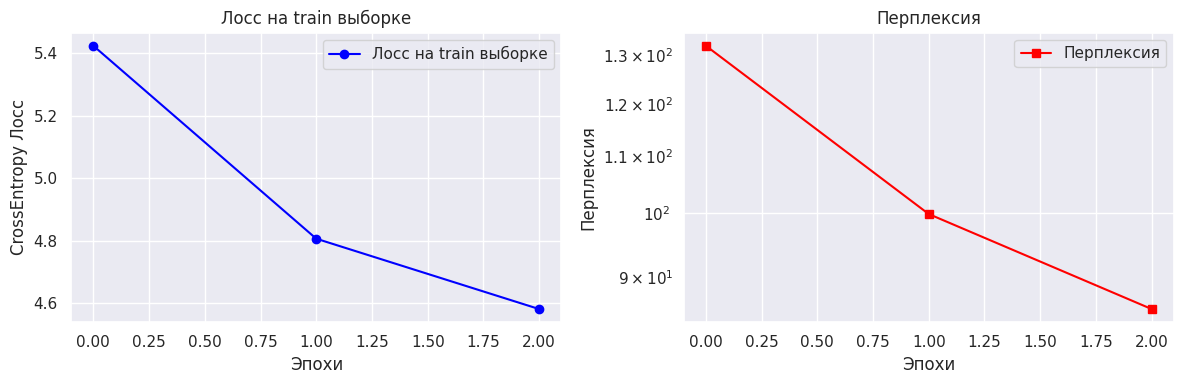

([5.424611802074282, 4.806155821247055, 4.580544665467806],
 [132.12724099963174, 99.89837716199563, 85.31020040033407])

In [ ]:
model = LanguageModel(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Модель работает. Переходим к экспериментам.

# Эксперименты

Проводимые эээээксперименты!

В рамках экспериментов было решено провести следующие эксперименты.

Эксперимент 1. Проверка влияния на качество моделей различных блоков RNN и числа реккурентных слоев.

Эксперимент 2. Проверяем влияние количества скрытых слоев.

Эскперимент 3.Проверяем влияние на результат различных функций оптимизации и параметра learning_rate.

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

Эксперимент №1.1. Меняем RNN-блок с GRU на LSTM. Также, добавляем слой нормализации.

In [ ]:
class LanguageModel_exp1_1_layer(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        #Поменял модель на LSTM, добавил еще один слой
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        #Также, добавляем слой нормализации
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.lstm(embeddings)
        output = self.layer_norm(output)
        return self.projection(output)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=171.3, eval_ppl=98.7


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=91.3, eval_ppl=72.4


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=68.8, eval_ppl=60.2


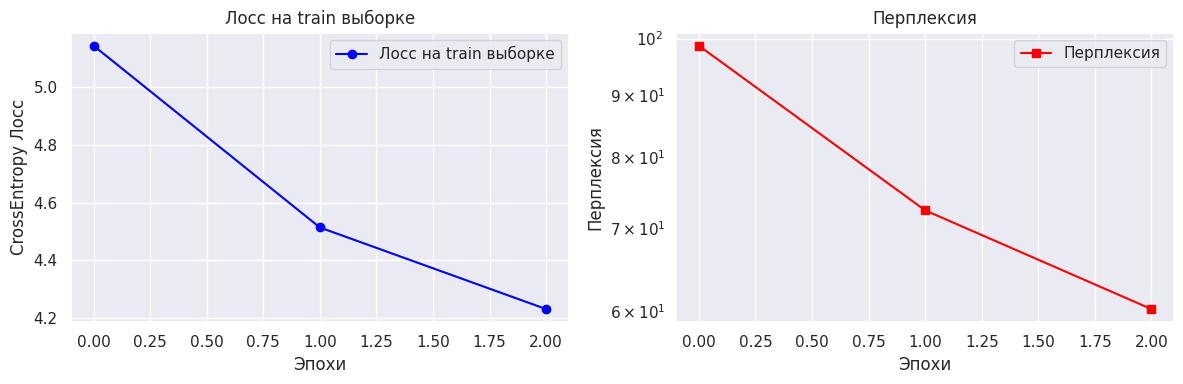

([5.143364599033028, 4.5141739987214535, 4.231625098330497],
 [98.662281895543, 72.44358002847993, 60.190979755062855])

In [ ]:
model = LanguageModel_exp1_1_layer(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Эксперимент №1.2. Увеличиваем число рекуррентных слоев блока LSTM на 2. Также, добавляем dropout = 0.1 между этими слоями.

In [ ]:
class LanguageModel_exp1_2_layer(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        #Поменял модель на LSTM, добавил еще один слой
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.1)
        #Также, добавляем слой нормализации
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.lstm(embeddings)
        output = self.layer_norm(output)
        return self.projection(output)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=165.6, eval_ppl=96.9


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=92.3, eval_ppl=71.3


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=70.5, eval_ppl=58.7


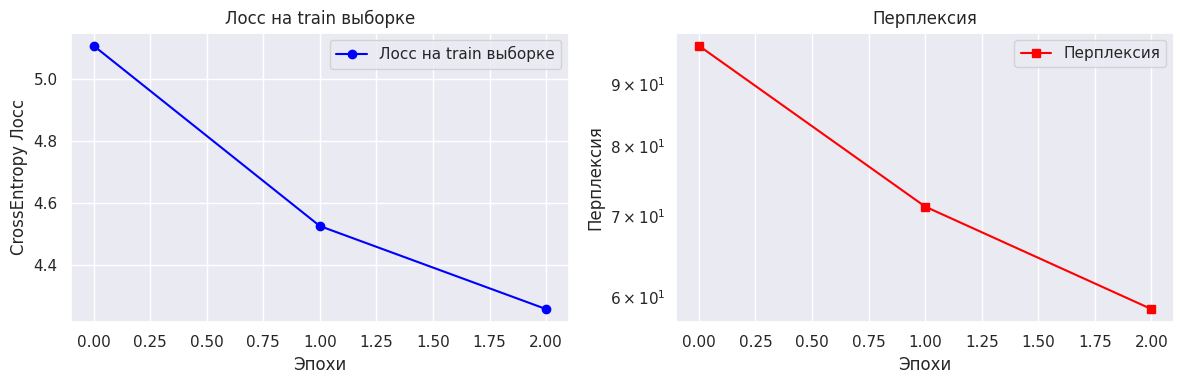

([5.109358659791831, 4.5252104457692575, 4.25625730711706],
 [96.92922254879042, 71.32347406905284, 58.65890340915518])

In [ ]:
model = LanguageModel_exp1_2_layer(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

### Второй эксперимент (2 балла)

Берем за основу базовую модель, но меняем число скрытых нейронов параметр hidden_dim.

Эксперимент №2.1. В рамках 1-го эксперимента увеличим hidden_dim до 512.

In [ ]:
class LanguageModel_exp2(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        return projection

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=145.6, eval_ppl=76.9


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=71.5, eval_ppl=52.8


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=47.9, eval_ppl=42.1


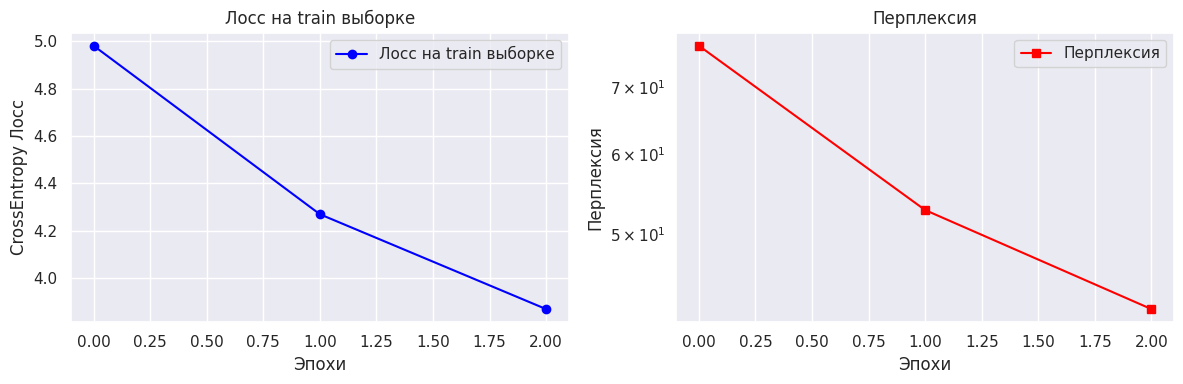

([4.980787011758032, 4.269256678686349, 3.8687450824393825],
 [76.94759366932676, 52.83913821756763, 42.12961730073317])

In [ ]:
model = LanguageModel_exp2(hidden_dim=512, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Эксперимент №2.2. Пробуем еще увеличить hidden_dim до 1024.

In [22]:
class LanguageModel_exp2_1(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        return projection

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=154.0, eval_ppl=80.6


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=79.0, eval_ppl=58.4


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=53.4, eval_ppl=46.6


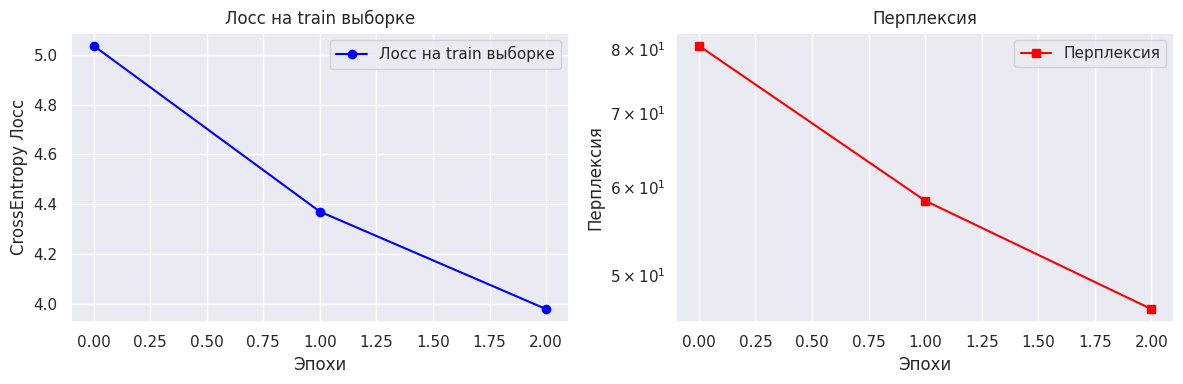

([5.03726777508675, 4.369858024586427, 3.9776809209791386],
 [80.61709026204113, 58.38888811973071, 46.59743730994265])

In [23]:
model = LanguageModel_exp2_1(hidden_dim=1024, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Сильно влияет на скорость. Время выполнения при числе эпох = 3 равно 30+ минут.

### Третий эксперимент

Рассмотрим различные типы алгоритма оптимизации: SGD, RMSProp, а также, различные значение learning rate.

За основу берем базовую модель.

In [24]:
class LanguageModel_exp3_1(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        return projection

Эксперимент №3.1. Оставляем в качестве оптимизатора Adam, но меняем learning_rare на 0.0005

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=274.9, eval_ppl=157.9


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=141.6, eval_ppl=120.0


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=114.9, eval_ppl=102.6


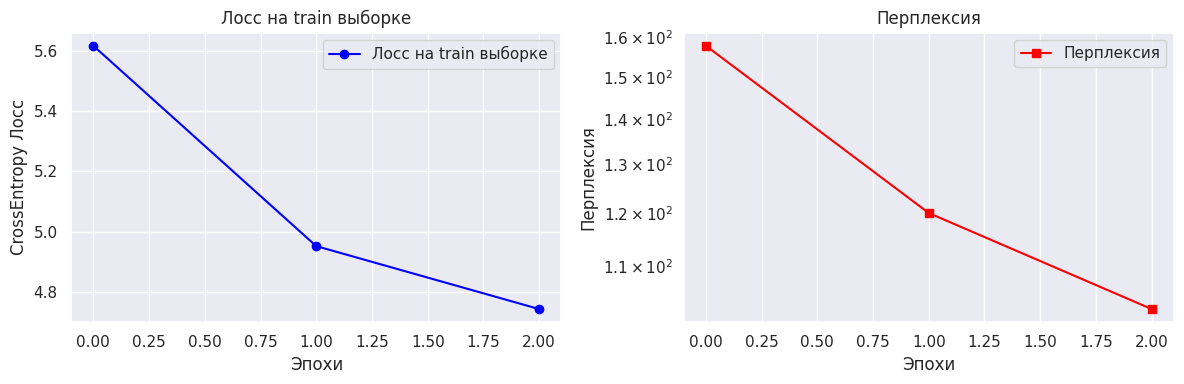

([5.616444871968448, 4.952682889860096, 4.7441327650510585],
 [157.8749597615717, 120.03622111513194, 102.56317274174636])

In [27]:
model = LanguageModel_exp3_1(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Эксперимент №3.2.1. Рассматриваем  в качестве оптимизатора RMSprop с learning_rare = 0.001

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=179.0, eval_ppl=128.6


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=118.1, eval_ppl=104.1


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=100.1, eval_ppl=91.8


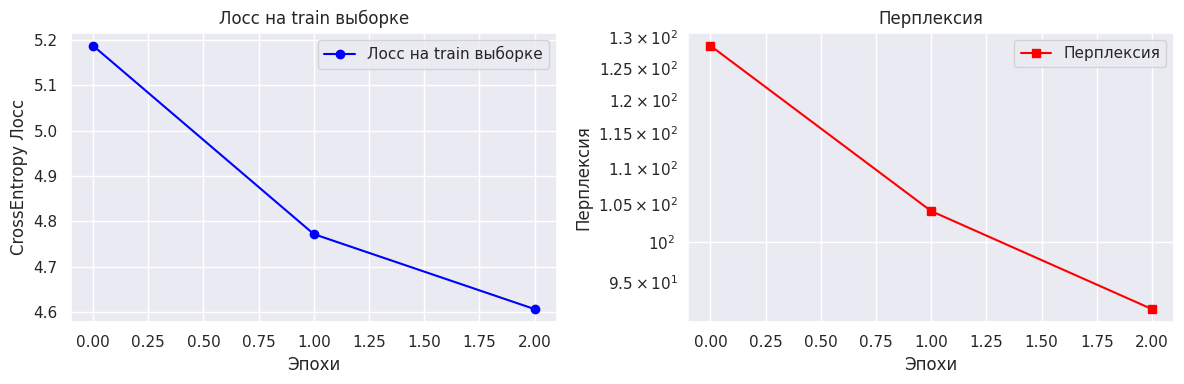

([5.187266040212765, 4.771801736790234, 4.606475591084119],
 [128.57988735086056, 104.07911524042353, 91.82332273308988])

In [25]:
model = LanguageModel_exp3_1(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Эксперимент №3.2.2. Оставляем оптимизатором RMSprop, меняем learning_rare на 0.0005

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=209.5, eval_ppl=154.8


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=138.3, eval_ppl=127.3


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=118.2, eval_ppl=112.8


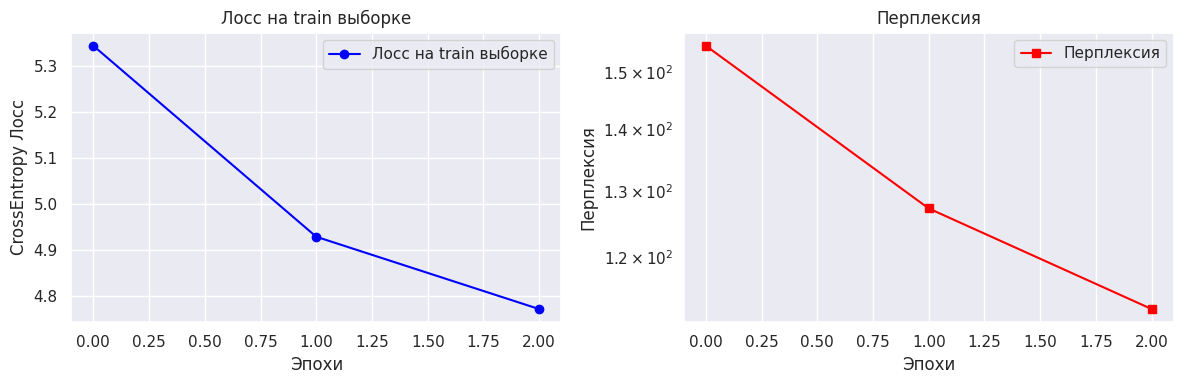

([5.344930764656343, 4.929475325494645, 4.772136027642248],
 [154.83960155354504, 127.29854376558478, 112.77919117302815])

In [28]:
model = LanguageModel_exp3_1(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.0005)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Эксперимент №3.3.1. Рассматриваем в качестве оптимизатора SGD с learning_rare = 0.01, momentun = 0.9

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=1072.7, eval_ppl=469.1


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=399.1, eval_ppl=348.7


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=321.7, eval_ppl=298.5


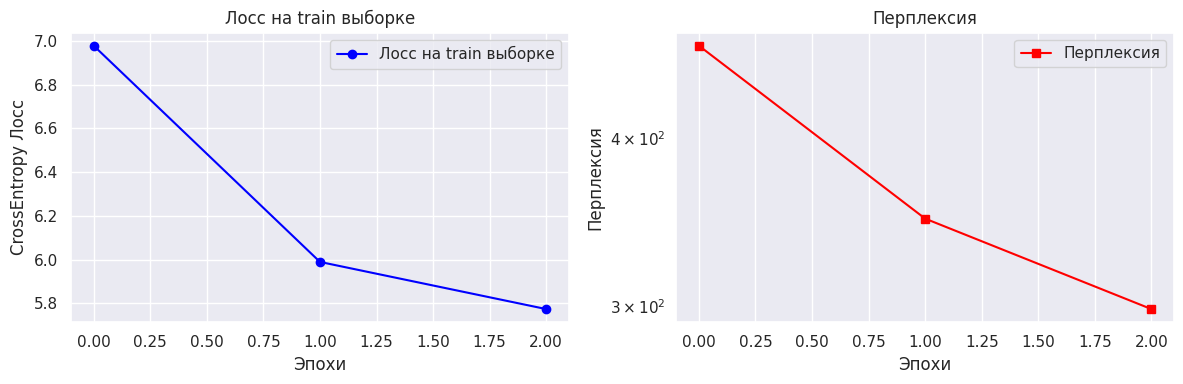

([6.977933162081558, 5.989284388786923, 5.773630846150921],
 [469.14249407401263, 348.66357217638955, 298.5184938880007])

In [31]:
model = LanguageModel_exp3_1(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

Эксперимент №3.2.2. Оставляем оптимизатором SGD, меняем learning_rare на 0.03

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=559.8, eval_ppl=300.4


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=262.5, eval_ppl=235.5


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=220.8, eval_ppl=207.0


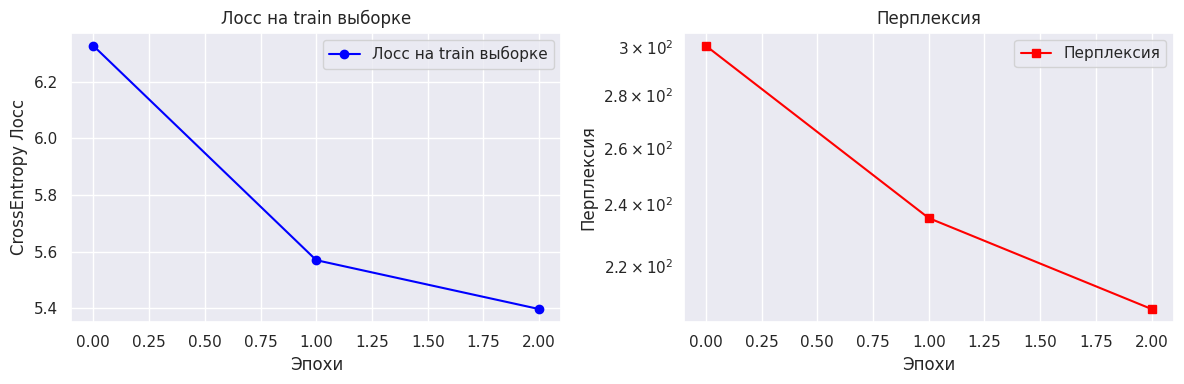

([6.32758159975035, 5.5700621309533584, 5.397195501089671],
 [300.4393161297458, 235.46617352302778, 207.03933992717256])

In [32]:
model = LanguageModel_exp3_1(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.SGD(model.parameters(), lr=0.03, momentum=0.9)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

## Бонус-эксперимент

Пробуем подтвердить гипотезу, что что функция ReLU дает результат хуже, чем Tanh.

In [ ]:
class LanguageModel_exp3(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.ReLU()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        return projection

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=217.8, eval_ppl=133.1


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=120.3, eval_ppl=100.7


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: train_ppl=95.3, eval_ppl=84.9


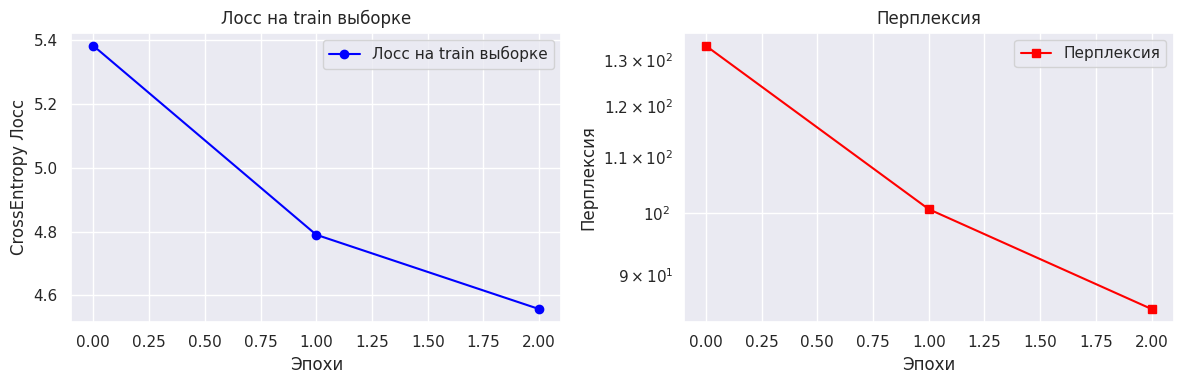

([5.383501578413088, 4.790235458797538, 4.55695967048958],
 [133.1301406997818, 100.7109870763359, 84.92001028073187])

In [ ]:
model = LanguageModel_exp3(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=3, optimizer=optimizer)

##Результаты

Представим табилцу сравнения результатов экспериментов

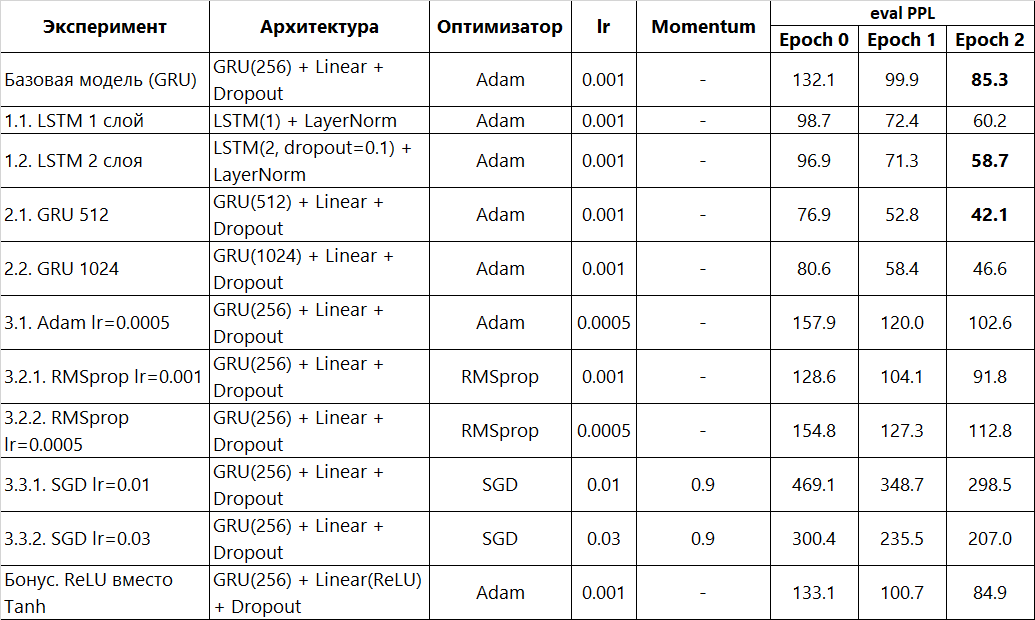

### Отчет (2 балла)

Проведено 11 экспериментов с языковой моделью на датасете IMDB.
В качестве базовой модели использовалась модель GRU(hidden_dim=256) с последующей линейной оптимизацией и Dropout = 0.1.
Было проведено несколько экспериментов:
1) LSTM варианты: 1 слой + LayerNorm, 2 слоя + dropout=0.1
2) Увеличение hidden_dim: GRU(hidden_dim=512), GRU(hidden_dim=1024)
3) Различные оптимизаторы: Adam (lr=0.0005/0.001), RMSprop (lr=0.0005/0.001), SGD (lr=0.01/0.03 + momentum=0.9)

Во всех эксперимента использовались следующие гиперпараметры: 3 эпохи, batch=128. В качестве метрики обучения использовалась перплексия на выборке eval.


Базовая модель показала eval PPL = 85.3. В ходе проведенного **эксперимента №3** Adam lr=0.001 показал стабильные результаты, SGD потребовал более тщательной настройки lr.

**Эксперимент №2** показал, что увеличение числа скрытых нейронов (hidden_dim) дает значимый результат к приросту качества модели. Проведенный эксперимент показал, что модель при hidden_dim = 512 демонстрирует лучший результат, чем при hidden_dim = 1024.
Стиот добавить, что увеличение данного параметра значительно влияет на время обучения. Общее время обучения и оценки при hidden_dim = 1024 составило ~10 минут на каждой эпохе. При hidden_dim = 256 время составило ~2.1 минуты на эпоху.

**Эксперимент №1**. Показал, что LSTM с нормализацией показывает лучший результат, чем базовая модель GRU. Изменение числа рекурсивных слоев, также, привел к улучшению результата. Однако, не слишком значимому.

Я думаю, что для улучшения качества моделей можно рассмотреть
модель LSTM с несколькими слоями, числом hidden_dim = 512 и большим числом эпох обучения.
Также, можно попробовать увеличить batch_size, протестировать разные значения lr для большего числа эпох.

Попробуем взять лучшие настройки и  увеличим число эпох.

In [33]:
class LanguageModel_optimum(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.1)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.lstm(embeddings)
        output = self.layer_norm(output)
        return self.projection(output)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 0: train_ppl=140.3, eval_ppl=77.4


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: train_ppl=73.1, eval_ppl=52.9


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Epoch 7: train_ppl=17.2, eval_ppl=24.4


Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 8: train_ppl=15.5, eval_ppl=23.2


Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 9: train_ppl=14.1, eval_ppl=22.3


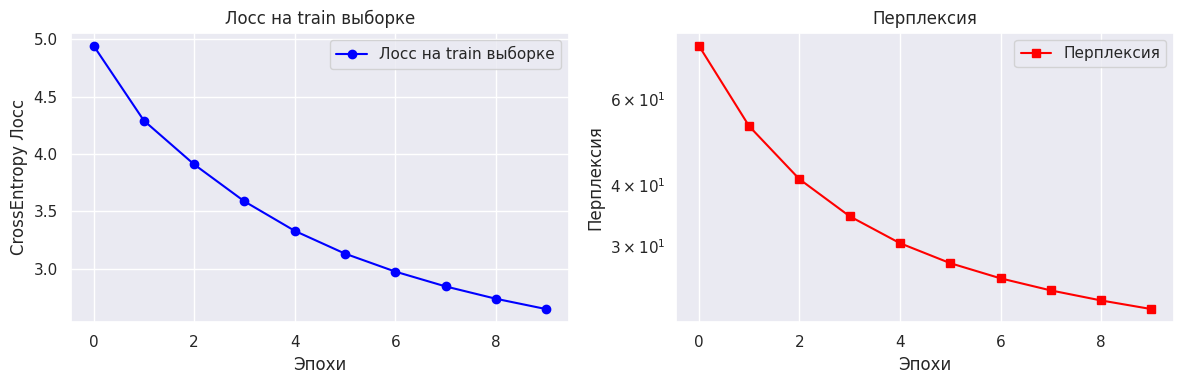

([4.943742566020472,
  4.291292944744721,
  3.909543843204133,
  3.587593626227958,
  3.3310071278845985,
  3.1325525335985525,
  2.976075247805251,
  2.8470934933457563,
  2.7396654713470325,
  2.6495460302524765],
 [77.39548631862017,
  52.91412796354355,
  41.20108586265927,
  34.57579128162281,
  30.450793076052477,
  27.707248439813366,
  25.791951210188895,
  24.362154272072104,
  23.234263987154574,
  22.30595062260769])

In [35]:
model = LanguageModel_optimum(hidden_dim=512, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, train_dataloader, eval_dataloader, num_epochs=10, optimizer=optimizer)

Как видно из результата обучения, модель с данными настройками показывает лучший результат за 3 эпохи (eval_ppl=41.2, что лучше чем все остальные эксперименты). За 10 эпох обучения модели перплексия на eval датасете снижается до eval_ppl=22.3. Однако, начиная с 5 эпохи наблюдается переобучение модели на train выборке.